# Wall-Correction Comparison -- Prop-Off & Prop-On

Compares **raw / uncorrected** coefficients against **wall-corrected (FINAL)** values.  
For prop-on force coefficients, a **BEM thrust-corrected** intermediate layer is also shown.

**Linestyle convention** (same across all plots):
- `--` dashed  -- raw / uncorrected
- `:` dotted   -- BEM thrust-corrected (prop-on force coefficients only)
- `-` solid    -- fully corrected (FINAL)

**Marker convention**:
- `o` circle   -- raw / uncorrected
- `^` triangle -- BEM thrust-corrected
- `s` square   -- fully corrected (FINAL)

**Colour** encodes J value (prop-on combined plots); correction layer is encoded by linestyle/marker.

**Sections**  
1. Setup & data loading  
2. Prop-Off (CL, CD, polar, CYaw, CMpitch, delta-alpha shift, multi-beta sweep)  
3. Prop-On (per-J individual figures + combined J=1.6/2.4 figures; polar overlay; delta increments)

## 1  Setup

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ── Paths — update to match your directory layout ─────────────────────────────
df_on  = pd.read_csv(r"CORRECTIONS_FINAL\results_propOn_FINAL\propOn_final.csv")
df_off = pd.read_csv(r"CORRECTIONS_FINAL\results_propOff_FINAL\propOff_final.csv")

# ── Global plot settings ──────────────────────────────────────────────────────
SHOW_TITLE = False
PLOT_DIR   = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                          "correction_comparison_plots")
os.makedirs(PLOT_DIR, exist_ok=True)

mpl.rcParams["axes.labelsize"]  = 12
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["axes.titlesize"]  = 12

# ── Marker convention ─────────────────────────────────────────────────────────
MK_RAW = "o"   # raw / uncorrected
MK_BEM = "^"   # BEM thrust-corrected (prop-on only)
MK_COR = "s"   # fully corrected FINAL
MS     = 5     # marker size

# ── Linestyle convention ──────────────────────────────────────────────────────
LS_RAW = "--"  # raw / uncorrected
LS_BEM = ":"   # BEM thrust-corrected
LS_COR = "-"   # fully corrected FINAL

In [62]:
# ── Colour palette — uncomment one line to switch all plots ──────────────────
import seaborn as sns

# PALETTE = "colorblind"  # accessible, best for publication (default)
PALETTE = "muted"       # soft, good for reports
# PALETTE = "deep"        # richer / bolder
# PALETTE = "tab10"       # matplotlib default
#PALETTE = "colorblind"

COLORS = sns.color_palette(PALETTE).as_hex()
print(f"Using palette: {PALETTE}")
print(f"Colours: {COLORS}")

Using palette: muted
Colours: ['#4878d0', '#ee854a', '#6acc64', '#d65f5f', '#956cb4', '#8c613c', '#dc7ec0', '#797979', '#d5bb67', '#82c6e2']


In [63]:
# ── Rounded helper columns ────────────────────────────────────────────────────
for _df in [df_on, df_off]:
    if "V_round"   not in _df.columns: _df["V_round"]   = _df["V"].round()
    if "AoS_round" not in _df.columns: _df["AoS_round"] = _df["AoS"].round()
    if "AoA_round" not in _df.columns: _df["AoA_round"] = _df["AoA"].round(1)

if "J_round" not in df_on.columns:
    df_on["J_round"] = df_on["J"].round(1)

# ── J values used in combined prop-on plots ───────────────────────────────────
J_COMBINED = [1.6, 2.4]   # only these two J values on combined figures

print("df_off shape:", df_off.shape)
print("df_on  shape:", df_on.shape)
print("Prop-off AoS values:", sorted(df_off["AoS_round"].unique()))
print("Prop-off dR  values:", sorted(df_off["dR"].unique()))
print("Prop-on  J   values:", sorted(df_on["J_round"].unique()))
print("Prop-on  dR  values:", sorted(df_on["dR"].unique()))

df_off shape: (4409, 68)
df_on  shape: (55, 156)
Prop-off AoS values: [np.float64(-10.0), np.float64(-8.0), np.float64(-5.0), np.float64(-4.0), np.float64(0.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(8.0), np.float64(10.0)]
Prop-off dR  values: [np.int64(-20), np.int64(-10), np.int64(0), np.int64(10), np.int64(20)]
Prop-on  J   values: [np.float64(1.6), np.float64(2.0), np.float64(2.4), np.float64(2.8)]
Prop-on  dR  values: [np.float64(-20.0), np.float64(-10.0), np.float64(-5.0), np.float64(0.0)]


---
## 2  Prop-Off -- raw vs corrected

Baseline filter: **V = 40 m/s · AoS = 0° · dR = 0° · dE = 0°**  
Sorted by actual AoA (not rounded) to avoid zigzag from repeated sweeps at the same nominal AoA.  
Raw = `--` dashed · Corrected FINAL = `-` solid

### 2.1  $C_L$ vs $\alpha$ -- raw vs corrected

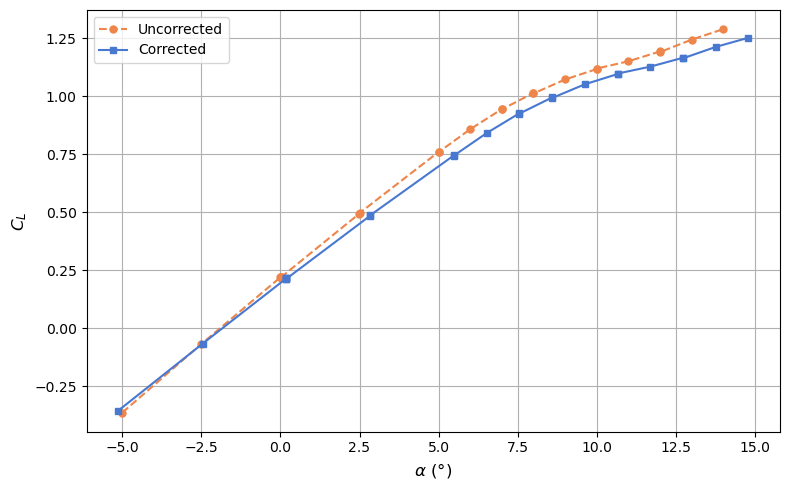

In [64]:
# -- Prop-off: CL vs AoA
df_base = df_off[
    (df_off["V_round"]   == 40) &
    (df_off["AoS_round"] == 0)  &
    (df_off["dR"]        == 0)  &
    (df_off["dE"]        == 0)
].copy().sort_values("AoA")   # sort by actual AoA to avoid zigzag from repeated sweeps

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_base["AoA"],       df_base["CL"],       marker=MK_RAW, markersize=MS,
        linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
ax.plot(df_base["AoA_FINAL"], df_base["CL_FINAL"], marker=MK_COR, markersize=MS,
        linestyle=LS_COR, color=COLORS[0], label="Corrected")

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_L$")
if SHOW_TITLE:
    ax.set_title(r"$C_L$ vs $\alpha$ -- Prop-off (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_CL_vs_AoA.png"), dpi=150)
plt.show()


### 2.2  $C_D$ vs $\alpha$ -- raw vs corrected

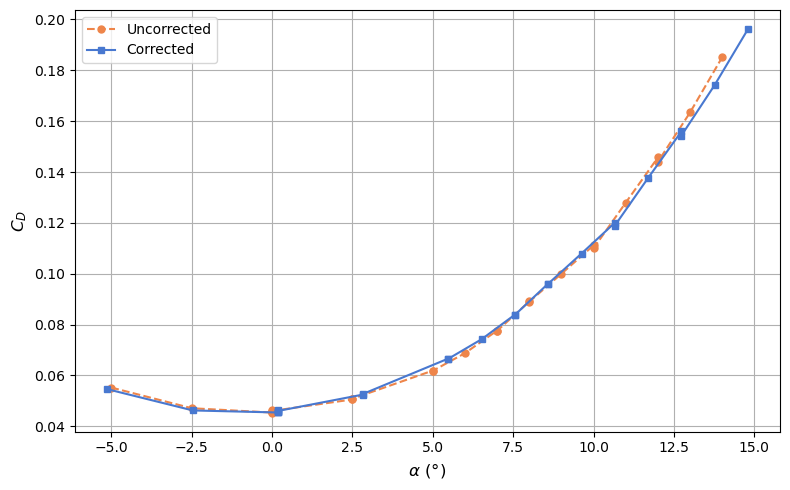

In [65]:
# -- Prop-off: CD vs AoA
df_base = df_off[
    (df_off["V_round"]   == 40) &
    (df_off["AoS_round"] == 0)  &
    (df_off["dR"]        == 0)  &
    (df_off["dE"]        == 0)
].copy().sort_values("AoA")   # sort by actual AoA to avoid zigzag from repeated sweeps

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_base["AoA"],       df_base["CD"],       marker=MK_RAW, markersize=MS,
        linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
ax.plot(df_base["AoA_FINAL"], df_base["CD_FINAL"], marker=MK_COR, markersize=MS,
        linestyle=LS_COR, color=COLORS[0], label="Corrected")

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(r"$C_D$ vs $\alpha$ -- Prop-off (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_CD_vs_AoA.png"), dpi=150)
plt.show()


### 2.3  Drag polar ($C_L$ vs $C_D$)

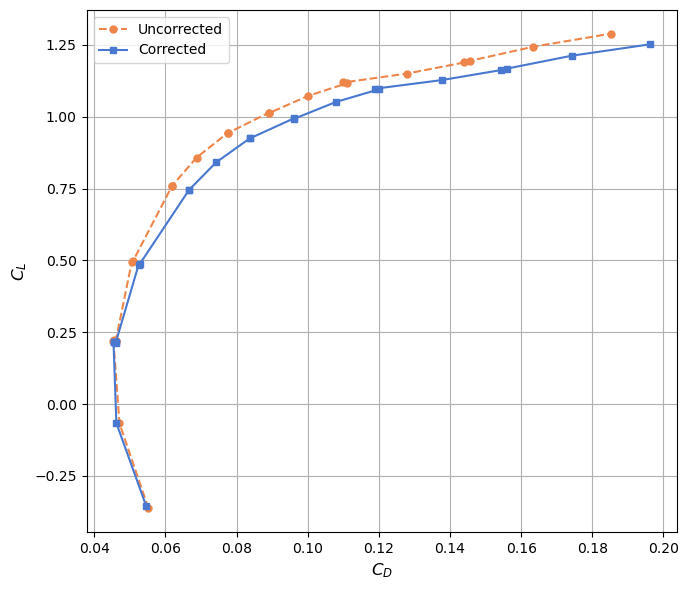

In [66]:
# -- Prop-off: drag polar (sorted by AoA for clean curve)
df_base = df_off[
    (df_off["V_round"]   == 40) &
    (df_off["AoS_round"] == 0)  &
    (df_off["dR"]        == 0)  &
    (df_off["dE"]        == 0)
].copy().sort_values("AoA")   # sort by actual AoA to avoid zigzag from repeated sweeps

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(df_base["CD"],       df_base["CL"],       marker=MK_RAW, markersize=MS,
        linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
ax.plot(df_base["CD_FINAL"], df_base["CL_FINAL"], marker=MK_COR, markersize=MS,
        linestyle=LS_COR, color=COLORS[0], label="Corrected")

ax.set_xlabel(r"$C_D$")
ax.set_ylabel(r"$C_L$")
if SHOW_TITLE:
    ax.set_title(r"Drag polar -- Prop-off (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_polar.png"), dpi=150)
plt.show()


### 2.4  $C_\mathrm{Yaw}$ vs $\alpha$

Duplicate points at the same nominal AoA are real repeated measurement sweeps (e.g. 5 runs at AoA $\approx$ 0°). Sorting by actual AoA rather than rounded AoA eliminates the zigzag between them.

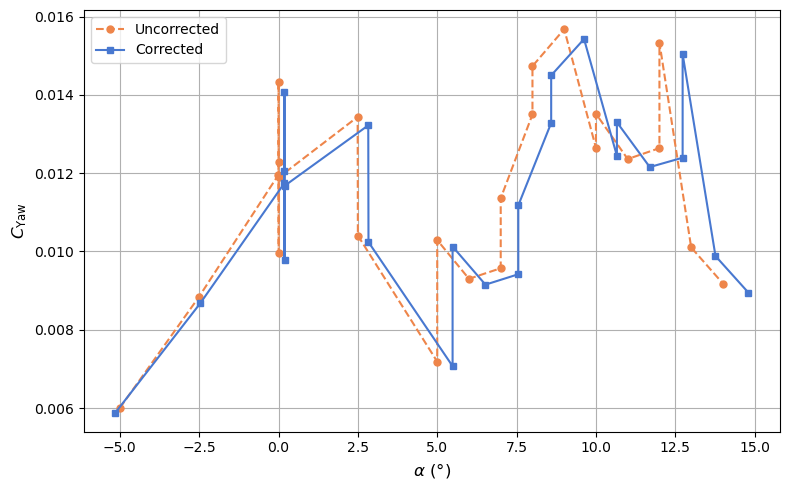

In [67]:
# -- Prop-off: CYaw vs AoA (sorted by actual AoA to fix zigzag from repeated sweeps)
df_base = df_off[
    (df_off["V_round"]   == 40) &
    (df_off["AoS_round"] == 0)  &
    (df_off["dR"]        == 0)  &
    (df_off["dE"]        == 0)
].copy().sort_values("AoA")   # sort by actual AoA to avoid zigzag from repeated sweeps

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_base["AoA"],       df_base["CYaw"],       marker=MK_RAW, markersize=MS,
        linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
ax.plot(df_base["AoA_FINAL"], df_base["CYaw_FINAL"], marker=MK_COR, markersize=MS,
        linestyle=LS_COR, color=COLORS[0], label="Corrected")

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_\mathrm{Yaw}$")
if SHOW_TITLE:
    ax.set_title(r"$C_\mathrm{Yaw}$ vs $\alpha$ -- Prop-off (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_CYaw_vs_AoA.png"), dpi=150)
plt.show()


### 2.5  $C_{M_\mathrm{pitch}}$ vs $\alpha$ -- raw vs corrected

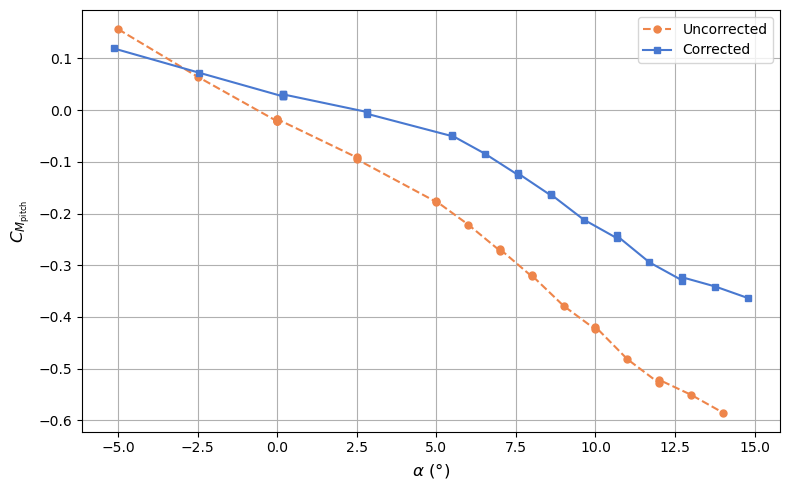

In [68]:
# -- Prop-off: CMpitch vs AoA
df_base = df_off[
    (df_off["V_round"]   == 40) &
    (df_off["AoS_round"] == 0)  &
    (df_off["dR"]        == 0)  &
    (df_off["dE"]        == 0)
].copy().sort_values("AoA")   # sort by actual AoA to avoid zigzag from repeated sweeps

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_base["AoA"],       df_base["CMpitch"],       marker=MK_RAW, markersize=MS,
        linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
ax.plot(df_base["AoA_FINAL"], df_base["CMpitch_FINAL"], marker=MK_COR, markersize=MS,
        linestyle=LS_COR, color=COLORS[0], label="Corrected")

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{pitch}}$ vs $\alpha$ -- Prop-off (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_CMpitch_vs_AoA.png"), dpi=150)
plt.show()


### 2.6  $C_{M_\mathrm{pitch}}$ vs $C_L$

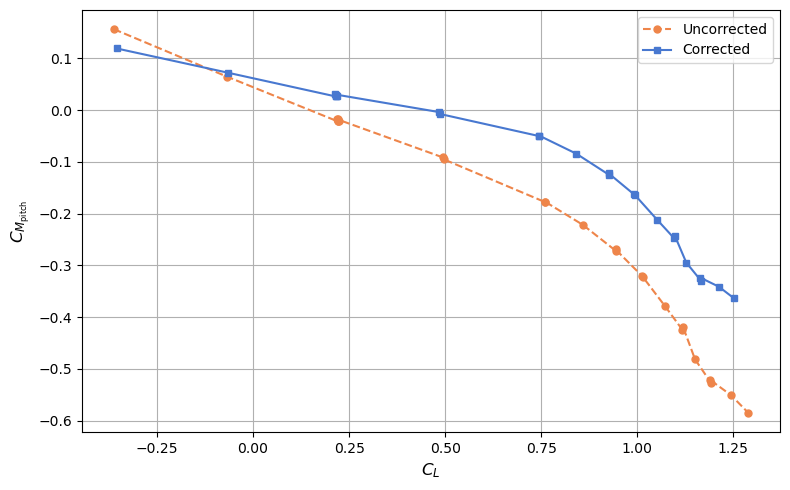

In [69]:
# -- Prop-off: CMpitch vs CL
df_base = df_off[
    (df_off["V_round"]   == 40) &
    (df_off["AoS_round"] == 0)  &
    (df_off["dR"]        == 0)  &
    (df_off["dE"]        == 0)
].copy().sort_values("AoA")   # sort by actual AoA to avoid zigzag from repeated sweeps

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_base["CL"],       df_base["CMpitch"],       marker=MK_RAW, markersize=MS,
        linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
ax.plot(df_base["CL_FINAL"], df_base["CMpitch_FINAL"], marker=MK_COR, markersize=MS,
        linestyle=LS_COR, color=COLORS[0], label="Corrected")

ax.set_xlabel(r"$C_L$")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{pitch}}$ vs $C_L$ -- Prop-off (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_CMpitch_vs_CL.png"), dpi=150)
plt.show()


### 2.7  $\Delta\alpha$ correction shift vs $\alpha_\mathrm{raw}$

Total AoA shift from all wall corrections (SC + downwash + tail), one line per AoS.

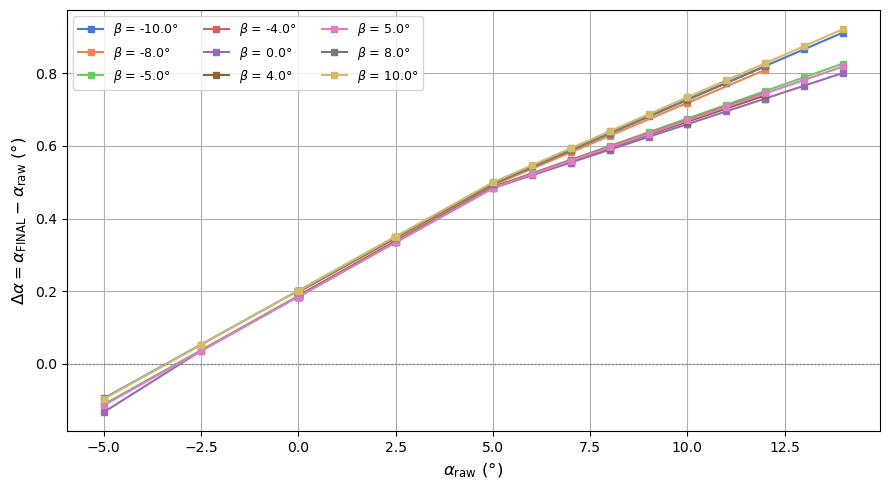

In [70]:
# -- Prop-off: delta-alpha vs raw AoA -- one line per AoS (V=40, dR=0, dE=0)
aos_values = sorted(df_off[
    (df_off["V_round"] == 40) & (df_off["dR"] == 0) & (df_off["dE"] == 0)
]["AoS_round"].unique())

fig, ax = plt.subplots(figsize=(9, 5))

for idx, aos in enumerate(aos_values):
    grp = df_off[
        (df_off["V_round"]   == 40) &
        (df_off["AoS_round"] == aos) &
        (df_off["dR"]        == 0)   &
        (df_off["dE"]        == 0)
    ].copy().sort_values("AoA")

    x     = grp["AoA"].to_numpy(dtype=float)
    delta = grp["AoA_FINAL"].to_numpy(dtype=float) - x
    fin   = np.isfinite(x) & np.isfinite(delta)
    if fin.sum() < 2:
        continue

    ax.plot(x[fin], delta[fin],
            marker=MK_COR, markersize=MS - 1, linestyle=LS_COR,
            color=COLORS[idx % len(COLORS)],
            label=fr"$\beta$ = {aos}°")

ax.axhline(0, color="gray", linestyle=":", linewidth=1.0)
ax.set_xlabel(r"$\alpha_\mathrm{raw}$ (°)")
ax.set_ylabel(r"$\Delta\alpha = \alpha_\mathrm{FINAL} - \alpha_\mathrm{raw}$ (°)")
if SHOW_TITLE:
    ax.set_title(r"$\Delta\alpha$ correction shift -- Prop-off (V = 40 m/s, $\delta_r$ = 0°)")
ax.legend(ncol=3, fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_delta_AoA_all_AoS.png"), dpi=150)
plt.show()


### 2.8  $C_L$ vs $\alpha$ -- multi-$\beta$ sweep (corrected)

FINAL lift curves for all AoS values tested at V = 40 m/s, dR = 0°.

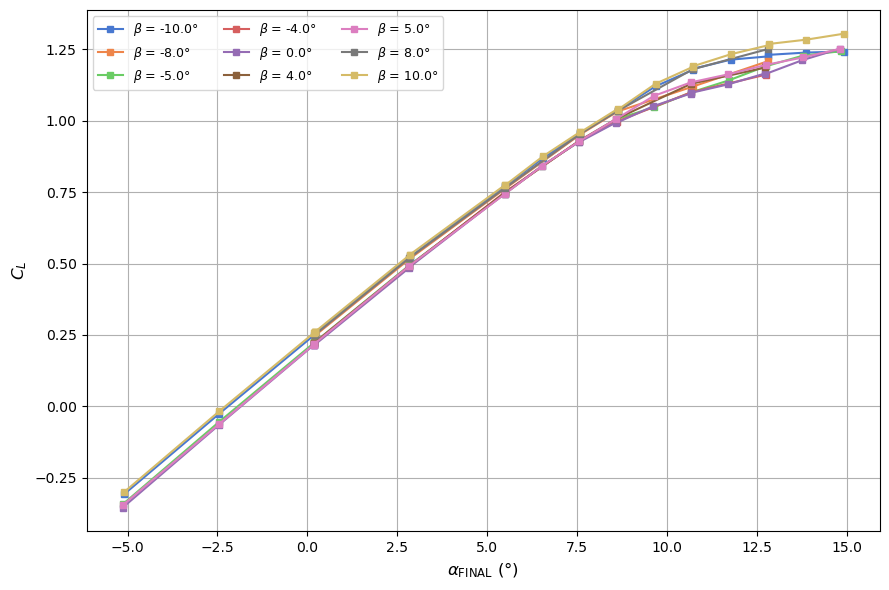

In [71]:
# -- Prop-off: CL vs AoA_FINAL -- one line per AoS
fig, ax = plt.subplots(figsize=(9, 6))

for idx, aos in enumerate(aos_values):
    grp = df_off[
        (df_off["V_round"]   == 40) &
        (df_off["AoS_round"] == aos) &
        (df_off["dR"]        == 0)   &
        (df_off["dE"]        == 0)
    ].copy().sort_values("AoA_FINAL")

    x = grp["AoA_FINAL"].to_numpy(dtype=float)
    y = grp["CL_FINAL"].to_numpy(dtype=float)
    fin = np.isfinite(x) & np.isfinite(y)
    if fin.sum() < 2:
        continue

    ax.plot(x[fin], y[fin],
            marker=MK_COR, markersize=MS - 1, linestyle=LS_COR,
            color=COLORS[idx % len(COLORS)],
            label=fr"$\beta$ = {aos}°")

ax.set_xlabel(r"$\alpha_\mathrm{FINAL}$ (°)")
ax.set_ylabel(r"$C_L$")
if SHOW_TITLE:
    ax.set_title(r"$C_L$ vs $\alpha$ (FINAL) -- Prop-off, V = 40 m/s, $\delta_r$ = 0°")
ax.legend(ncol=3, fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_CL_vs_AoA_FINAL_all_AoS.png"), dpi=150)
plt.show()


---
## 3  Prop-On -- three correction layers

Baseline filter: **V = 40 m/s · AoS = 0° · dR = 0°**

Each subsection produces:
- **Individual figures** per J value (all J values; same style as before)
- **Combined figure** with J = 1.6 and J = 2.4 on the same axes  
  Colour encodes J · Linestyle encodes correction layer (`--` raw, `:` BEM, `-` FINAL)

Force coefficients (CL, CD, CYaw): three series -- raw, BEM, FINAL.  
Moment coefficients (CMpitch, CMyaw): raw vs FINAL only (no BEM intermediate).

### 3.1  $C_L$ vs $\alpha$

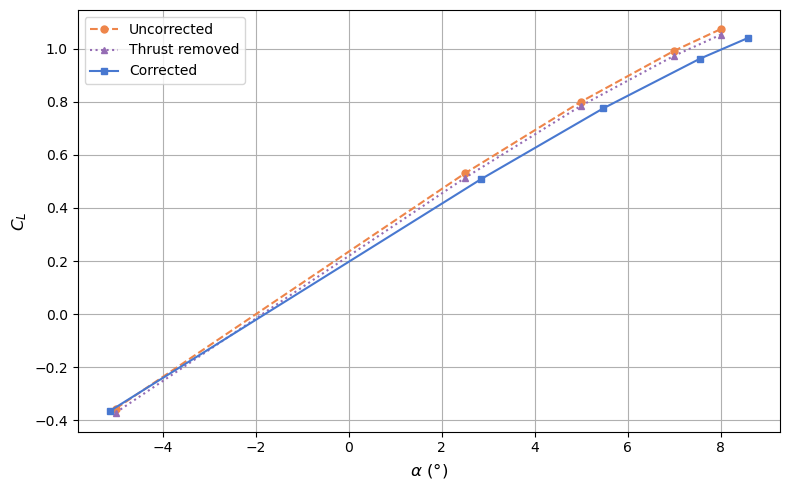

Saved: propon_CL_vs_AoA_J1p6ppng


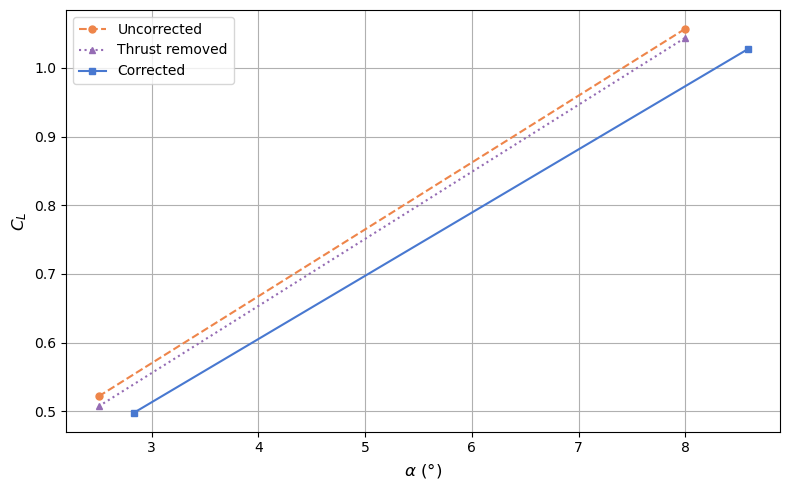

Saved: propon_CL_vs_AoA_J2p0ppng


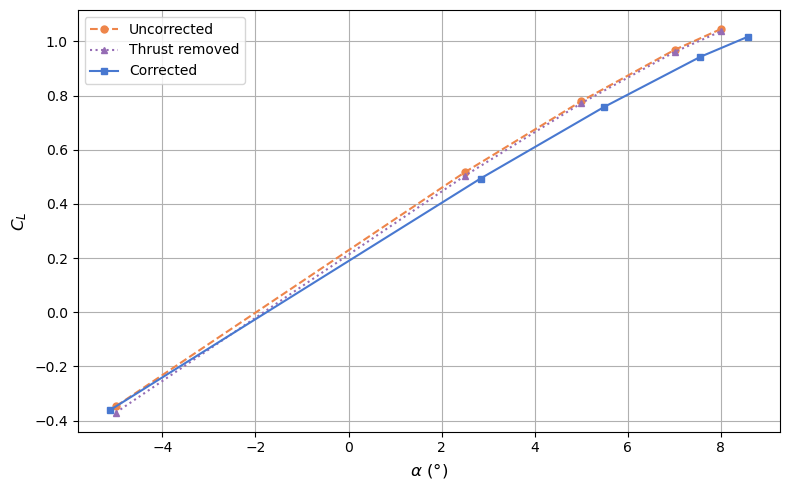

Saved: propon_CL_vs_AoA_J2p4ppng


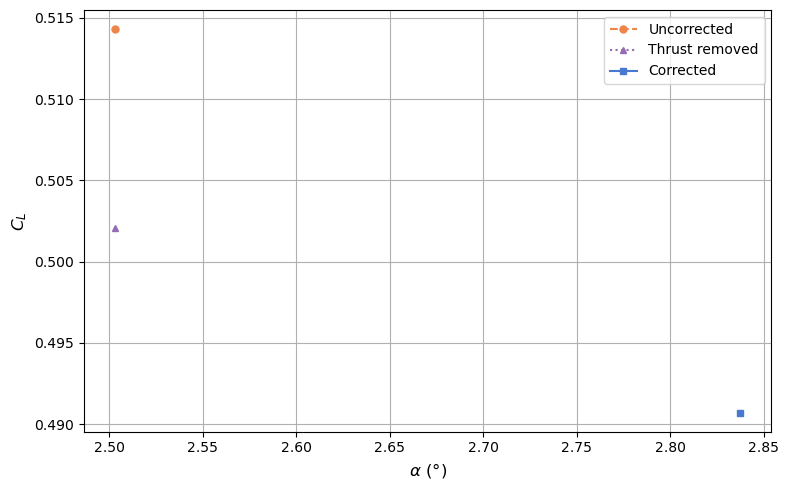

Saved: propon_CL_vs_AoA_J2p8ppng


In [72]:
# -- Prop-on: CL vs AoA -- individual figure per J (all J values)
j_values_all = sorted(df_on["J_round"].unique())

for j_val in j_values_all:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    x_aoa = grp["AoA"].to_numpy(dtype=float)
    x_fin = grp["AoA_FINAL"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_aoa, grp["CL"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
    ax.plot(x_aoa, grp["CL_aero_BEM"].to_numpy(dtype=float),
            marker=MK_BEM, markersize=MS, linestyle=LS_BEM, color=COLORS[4], label="Thrust removed")
    ax.plot(x_fin, grp["CL_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR, color=COLORS[0], label="Corrected")

    ax.set_xlabel(r"$\alpha$ (°)")
    ax.set_ylabel(r"$C_L$")
    if SHOW_TITLE:
        ax.set_title(fr"$C_L$ vs $\alpha$ -- Prop-on ($J$ = {j_val})")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    save_name = f"propon_CL_vs_AoA_J{j_val}.png".replace(".", "p")
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=150)
    plt.show()
    print(f"Saved: {save_name}")


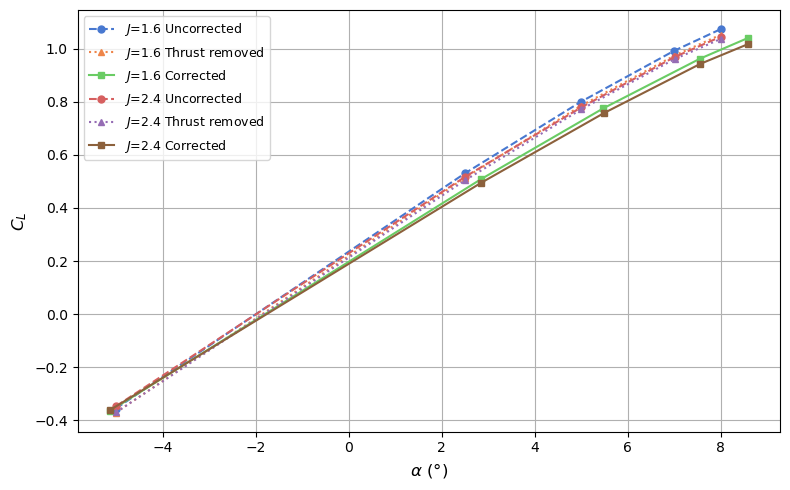

In [73]:
# -- Prop-on: CL vs AoA -- combined figure J=1.6 and J=2.4
# 6 distinct colours: 3 per J, cycled sequentially (colour encodes individual line)
fig, ax = plt.subplots(figsize=(8, 5))

color_idx = 0
for j_val in J_COMBINED:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    x_aoa = grp["AoA"].to_numpy(dtype=float)
    x_fin = grp["AoA_FINAL"].to_numpy(dtype=float)

    ax.plot(x_aoa, grp["CL"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW,
            color=COLORS[color_idx], label=fr"$J$={j_val} Uncorrected")
    ax.plot(x_aoa, grp["CL_aero_BEM"].to_numpy(dtype=float),
            marker=MK_BEM, markersize=MS, linestyle=LS_BEM,
            color=COLORS[color_idx + 1], label=fr"$J$={j_val} Thrust removed")
    ax.plot(x_fin, grp["CL_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[color_idx + 2], label=fr"$J$={j_val} Corrected")
    color_idx += 3

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_L$")
if SHOW_TITLE:
    ax.set_title(r"$C_L$ vs $\alpha$ -- Prop-on, $J$ = 1.6 & 2.4 (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_CL_vs_AoA_J16_J24_combined.png"), dpi=150)
plt.show()


### 3.2  $C_D$ vs $\alpha$

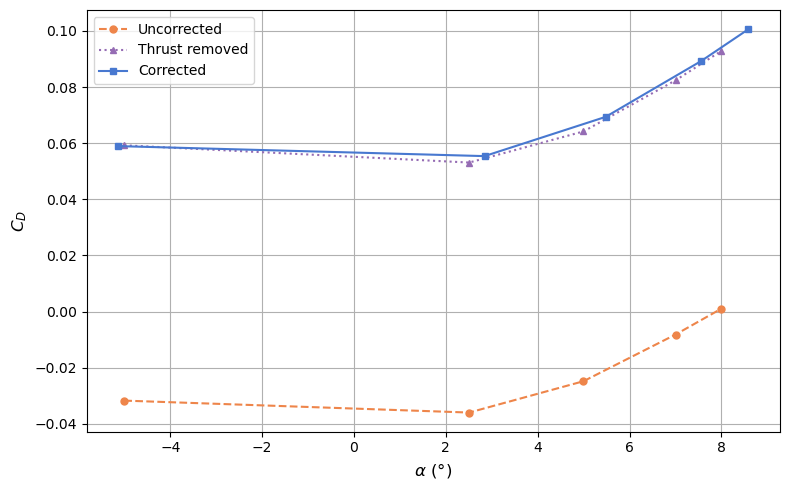

Saved: propon_CD_vs_AoA_J1p6ppng


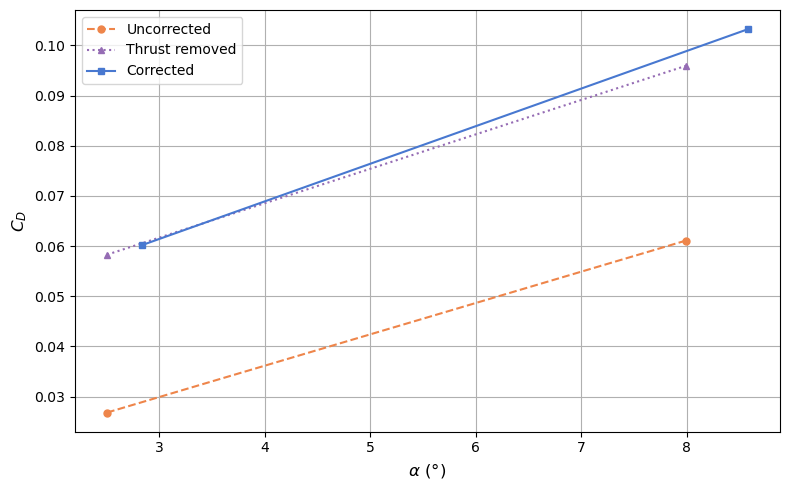

Saved: propon_CD_vs_AoA_J2p0ppng


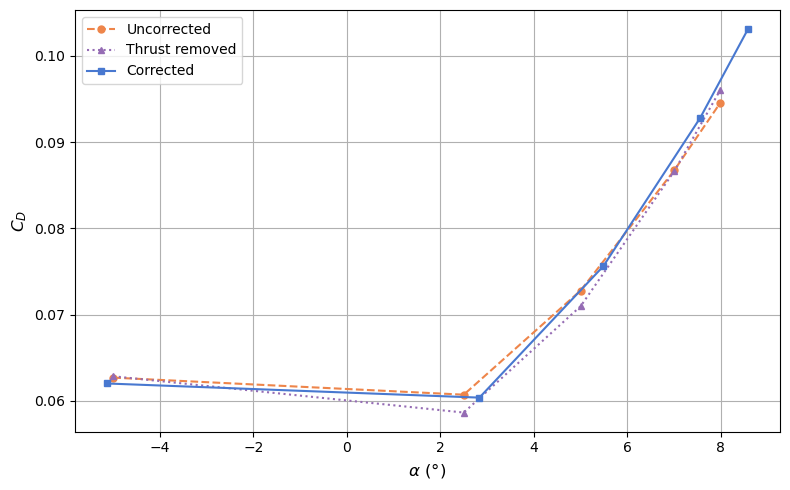

Saved: propon_CD_vs_AoA_J2p4ppng


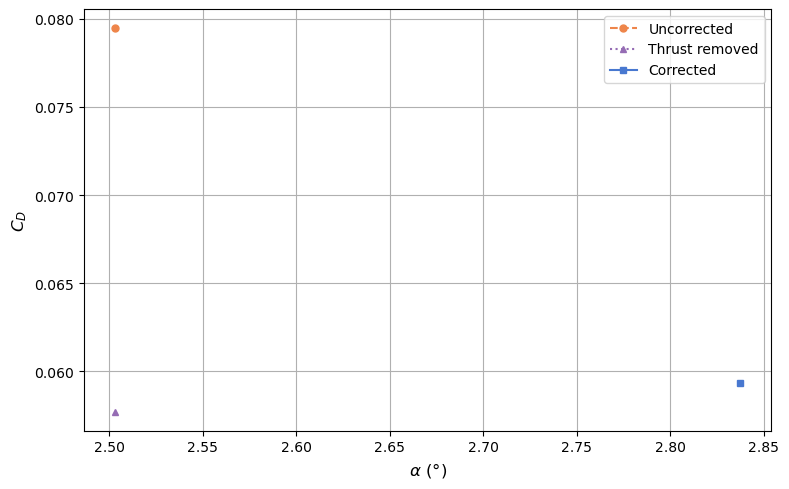

Saved: propon_CD_vs_AoA_J2p8ppng


In [74]:
# -- Prop-on: CD vs AoA -- individual figure per J (all J values)
j_values_all = sorted(df_on["J_round"].unique())

for j_val in j_values_all:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    x_aoa = grp["AoA"].to_numpy(dtype=float)
    x_fin = grp["AoA_FINAL"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_aoa, grp["CD"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
    ax.plot(x_aoa, grp["CD_aero_BEM"].to_numpy(dtype=float),
            marker=MK_BEM, markersize=MS, linestyle=LS_BEM, color=COLORS[4], label="Thrust removed")
    ax.plot(x_fin, grp["CD_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR, color=COLORS[0], label="Corrected")

    ax.set_xlabel(r"$\alpha$ (°)")
    ax.set_ylabel(r"$C_D$")
    if SHOW_TITLE:
        ax.set_title(fr"$C_D$ vs $\alpha$ -- Prop-on ($J$ = {j_val})")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    save_name = f"propon_CD_vs_AoA_J{j_val}.png".replace(".", "p")
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=150)
    plt.show()
    print(f"Saved: {save_name}")


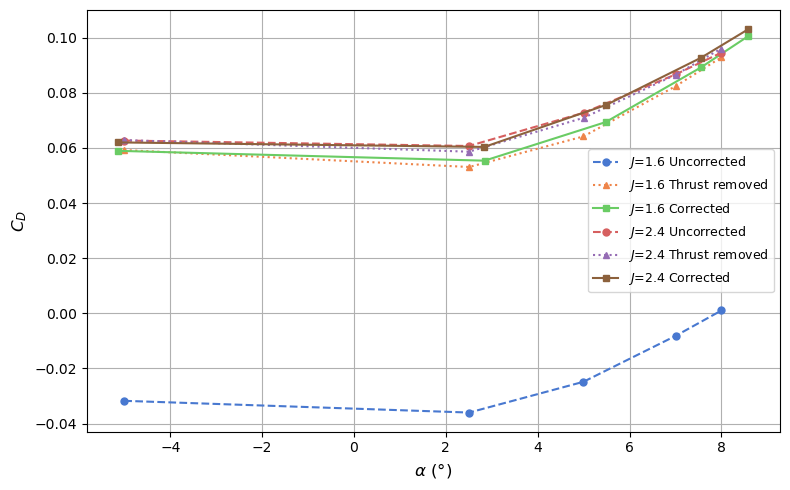

In [75]:
# -- Prop-on: CD vs AoA -- combined figure J=1.6 and J=2.4
# 6 distinct colours: 3 per J, cycled sequentially (colour encodes individual line)
fig, ax = plt.subplots(figsize=(8, 5))

color_idx = 0
for j_val in J_COMBINED:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    x_aoa = grp["AoA"].to_numpy(dtype=float)
    x_fin = grp["AoA_FINAL"].to_numpy(dtype=float)

    ax.plot(x_aoa, grp["CD"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW,
            color=COLORS[color_idx], label=fr"$J$={j_val} Uncorrected")
    ax.plot(x_aoa, grp["CD_aero_BEM"].to_numpy(dtype=float),
            marker=MK_BEM, markersize=MS, linestyle=LS_BEM,
            color=COLORS[color_idx + 1], label=fr"$J$={j_val} Thrust removed")
    ax.plot(x_fin, grp["CD_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[color_idx + 2], label=fr"$J$={j_val} Corrected")
    color_idx += 3

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(r"$C_D$ vs $\alpha$ -- Prop-on, $J$ = 1.6 & 2.4 (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_CD_vs_AoA_J16_J24_combined.png"), dpi=150)
plt.show()


### 3.3  $C_\mathrm{Yaw}$ vs $\alpha$

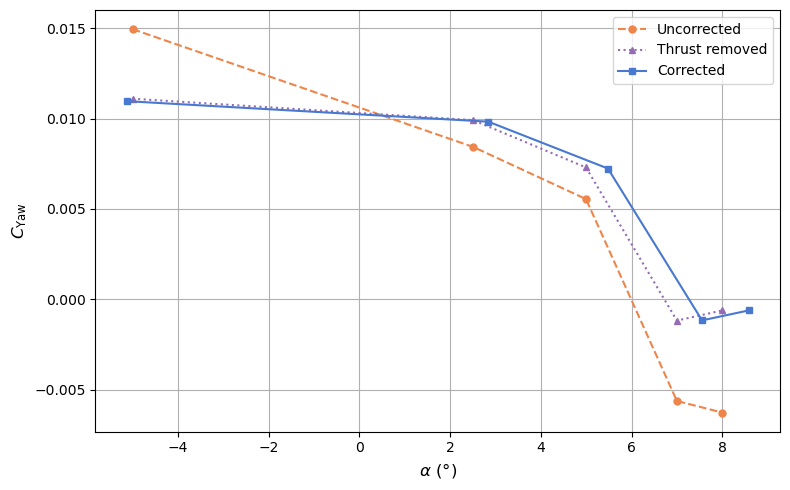

Saved: propon_CYaw_vs_AoA_J1p6ppng


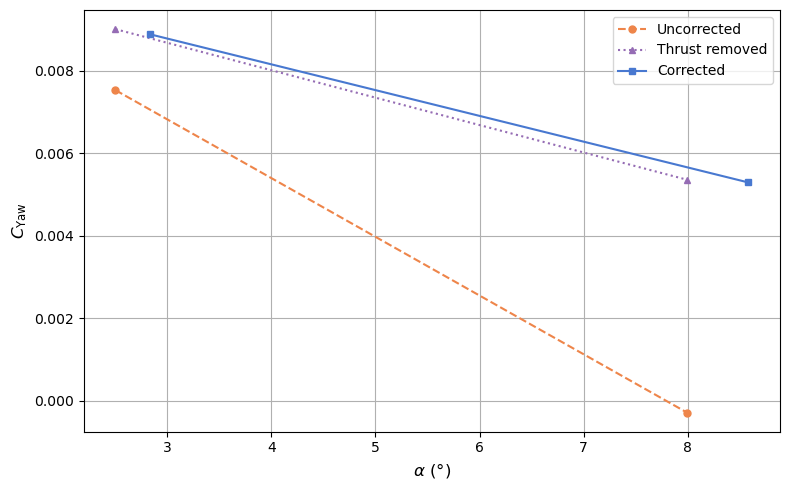

Saved: propon_CYaw_vs_AoA_J2p0ppng


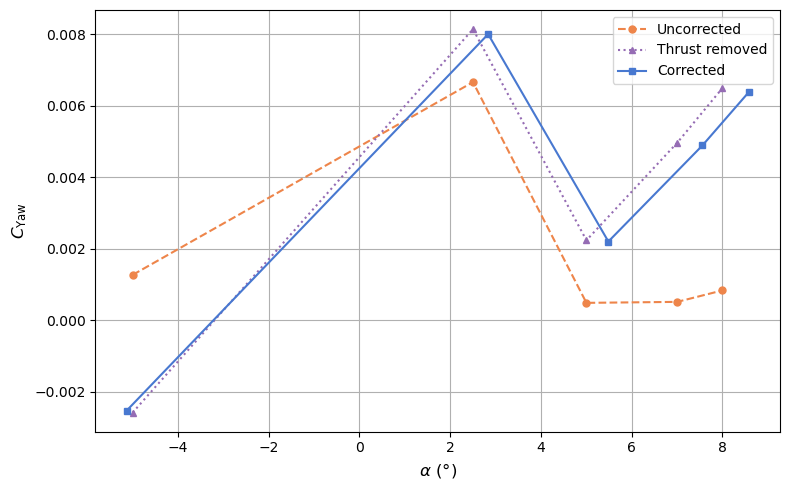

Saved: propon_CYaw_vs_AoA_J2p4ppng


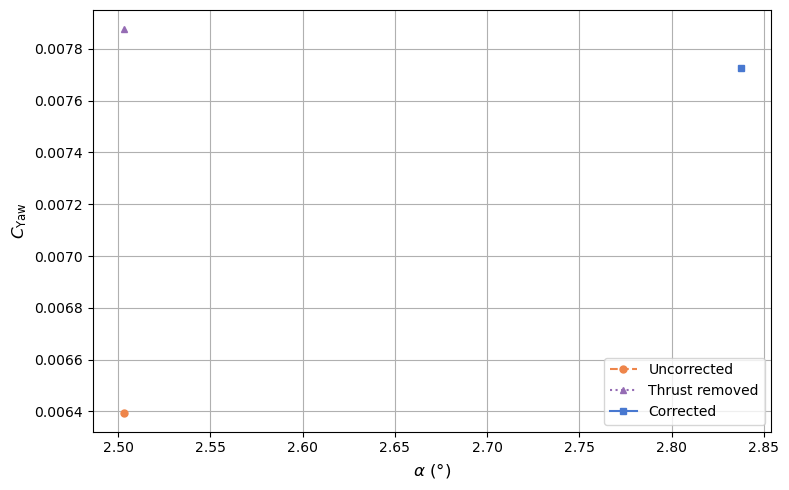

Saved: propon_CYaw_vs_AoA_J2p8ppng


In [76]:
# -- Prop-on: CYaw vs AoA -- individual figure per J (all J values)
j_values_all = sorted(df_on["J_round"].unique())

for j_val in j_values_all:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    x_aoa = grp["AoA"].to_numpy(dtype=float)
    x_fin = grp["AoA_FINAL"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_aoa, grp["CYaw"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
    ax.plot(x_aoa, grp["CYaw_aero_BEM"].to_numpy(dtype=float),
            marker=MK_BEM, markersize=MS, linestyle=LS_BEM, color=COLORS[4], label="Thrust removed")
    ax.plot(x_fin, grp["CYaw_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR, color=COLORS[0], label="Corrected")

    ax.set_xlabel(r"$\alpha$ (°)")
    ax.set_ylabel(r"$C_\mathrm{Yaw}$")
    if SHOW_TITLE:
        ax.set_title(fr"$C_\mathrm{{Yaw}}$ vs $\alpha$ -- Prop-on ($J$ = {j_val})")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    save_name = f"propon_CYaw_vs_AoA_J{j_val}.png".replace(".", "p")
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=150)
    plt.show()
    print(f"Saved: {save_name}")


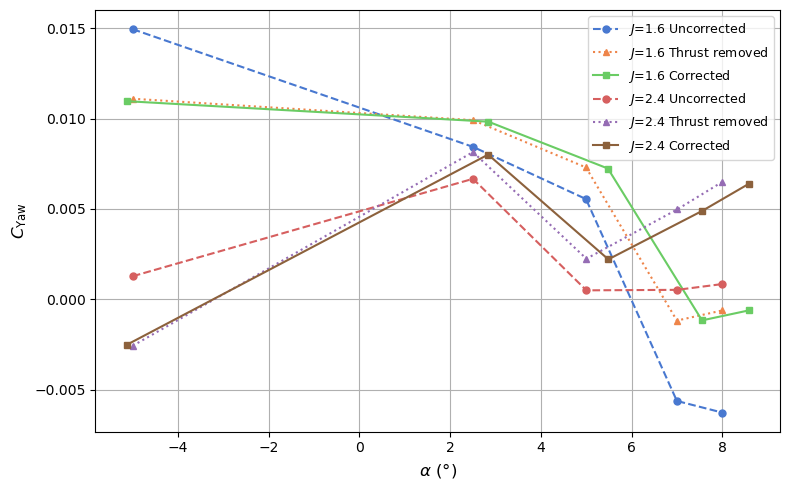

In [77]:
# -- Prop-on: CYaw vs AoA -- combined figure J=1.6 and J=2.4
# 6 distinct colours: 3 per J, cycled sequentially (colour encodes individual line)
fig, ax = plt.subplots(figsize=(8, 5))

color_idx = 0
for j_val in J_COMBINED:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    x_aoa = grp["AoA"].to_numpy(dtype=float)
    x_fin = grp["AoA_FINAL"].to_numpy(dtype=float)

    ax.plot(x_aoa, grp["CYaw"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW,
            color=COLORS[color_idx], label=fr"$J$={j_val} Uncorrected")
    ax.plot(x_aoa, grp["CYaw_aero_BEM"].to_numpy(dtype=float),
            marker=MK_BEM, markersize=MS, linestyle=LS_BEM,
            color=COLORS[color_idx + 1], label=fr"$J$={j_val} Thrust removed")
    ax.plot(x_fin, grp["CYaw_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[color_idx + 2], label=fr"$J$={j_val} Corrected")
    color_idx += 3

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_\mathrm{Yaw}$")
if SHOW_TITLE:
    ax.set_title(r"$C_\mathrm{Yaw}$ vs $\alpha$ -- Prop-on, $J$ = 1.6 & 2.4 (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_CYaw_vs_AoA_J16_J24_combined.png"), dpi=150)
plt.show()


### 3.4  $C_{M_\mathrm{pitch}}$ vs $\alpha$

No BEM-separated intermediate column for moment coefficients.

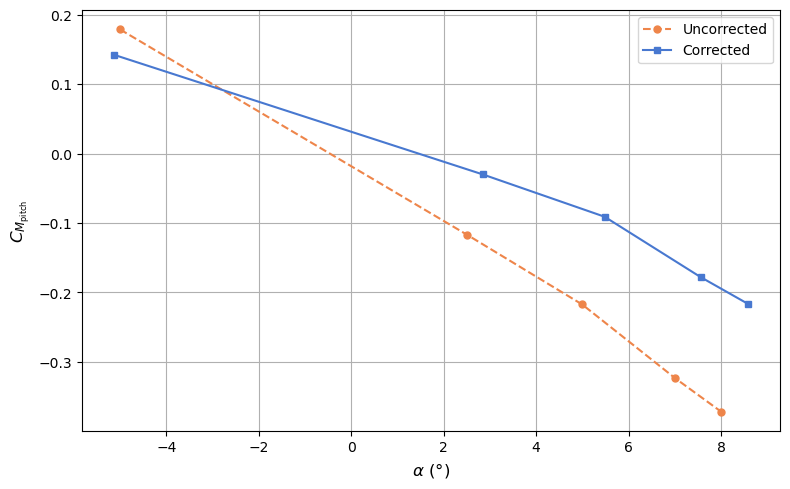

Saved: propon_CMpitch_vs_AoA_J1p6ppng


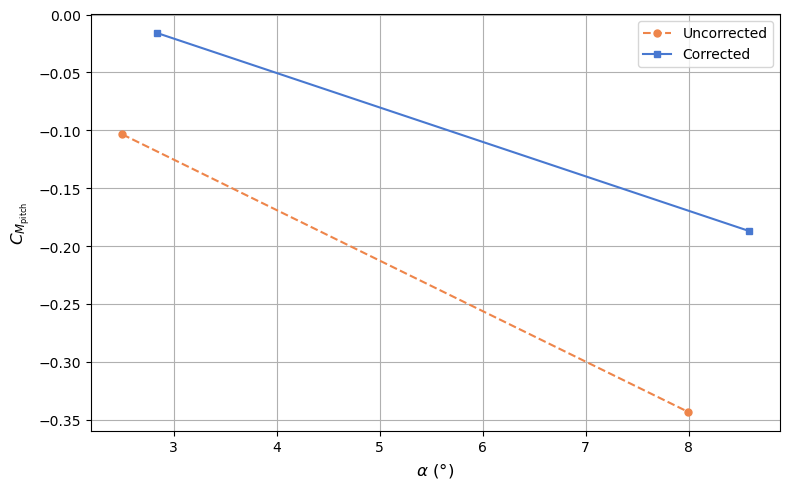

Saved: propon_CMpitch_vs_AoA_J2p0ppng


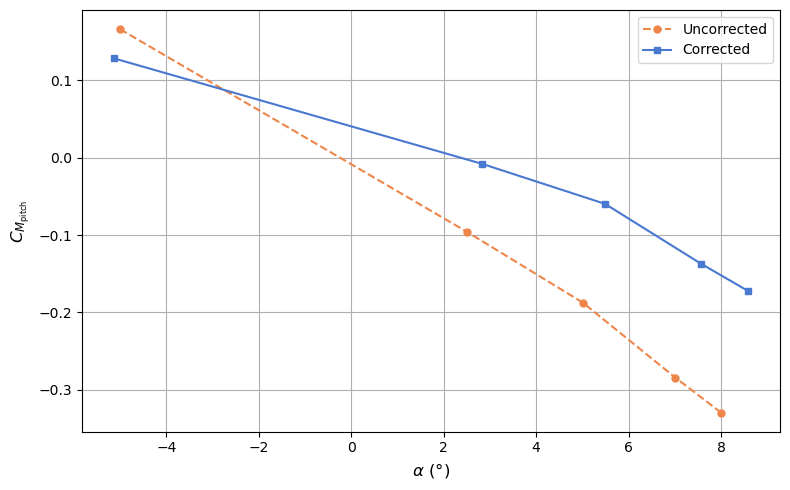

Saved: propon_CMpitch_vs_AoA_J2p4ppng


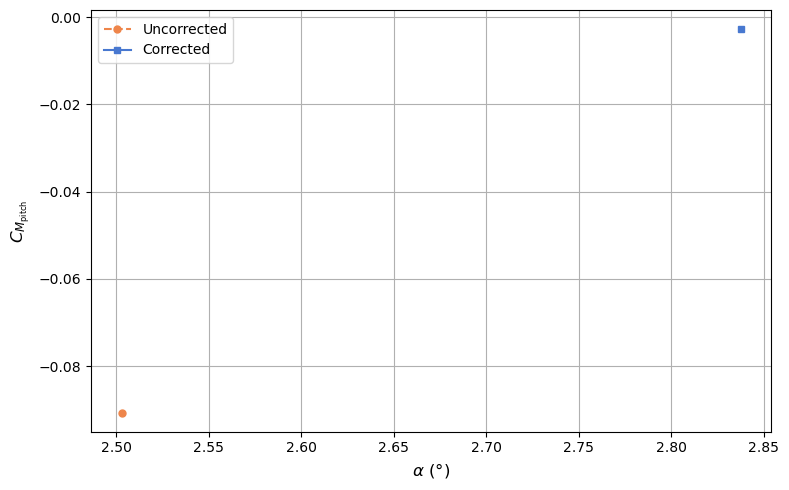

Saved: propon_CMpitch_vs_AoA_J2p8ppng


In [78]:
# -- Prop-on: CMpitch vs AoA -- individual figure per J (all J values)
j_values_all = sorted(df_on["J_round"].unique())

for j_val in j_values_all:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    x_aoa = grp["AoA"].to_numpy(dtype=float)
    x_fin = grp["AoA_FINAL"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_aoa, grp["CMpitch"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
    ax.plot(x_fin, grp["CMpitch_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR, color=COLORS[0], label="Corrected")

    ax.set_xlabel(r"$\alpha$ (°)")
    ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
    if SHOW_TITLE:
        ax.set_title(fr"$C_{{M_\mathrm{{pitch}}}}$ vs $\alpha$ -- Prop-on ($J$ = {j_val})")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    save_name = f"propon_CMpitch_vs_AoA_J{j_val}.png".replace(".", "p")
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=150)
    plt.show()
    print(f"Saved: {save_name}")


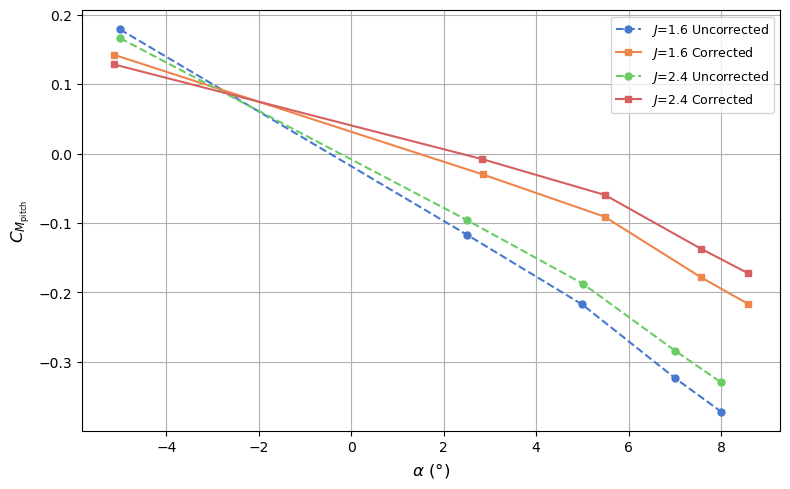

In [79]:
# -- Prop-on: CMpitch vs AoA -- combined figure J=1.6 and J=2.4
# 4 distinct colours: 2 per J, cycled sequentially (colour encodes individual line)
fig, ax = plt.subplots(figsize=(8, 5))

color_idx = 0
for j_val in J_COMBINED:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    ax.plot(grp["AoA"].to_numpy(dtype=float), grp["CMpitch"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW,
            color=COLORS[color_idx], label=fr"$J$={j_val} Uncorrected")
    ax.plot(grp["AoA_FINAL"].to_numpy(dtype=float), grp["CMpitch_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[color_idx + 1], label=fr"$J$={j_val} Corrected")
    color_idx += 2

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{pitch}}$ vs $\alpha$ -- Prop-on, $J$ = 1.6 & 2.4 (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_CMpitch_vs_AoA_J16_J24_combined.png"), dpi=150)
plt.show()


### 3.5  $C_{M_\mathrm{yaw}}$ vs $\alpha$

No BEM-separated intermediate column for moment coefficients.

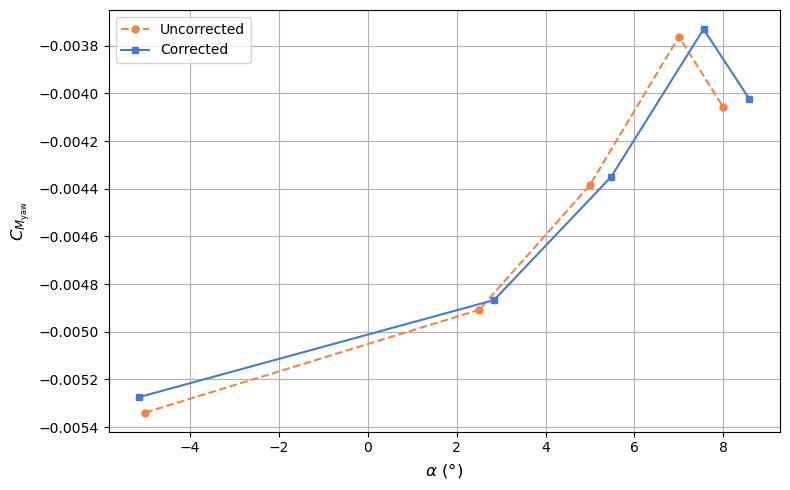

Saved: propon_CMyaw_vs_AoA_J1p6ppng


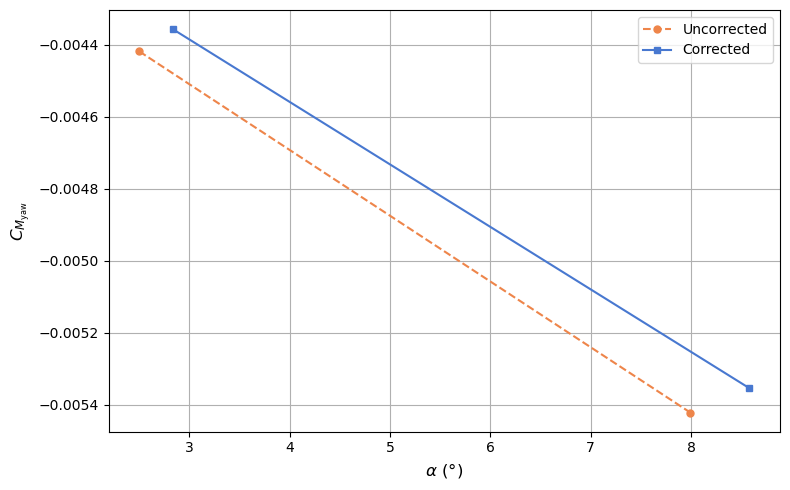

Saved: propon_CMyaw_vs_AoA_J2p0ppng


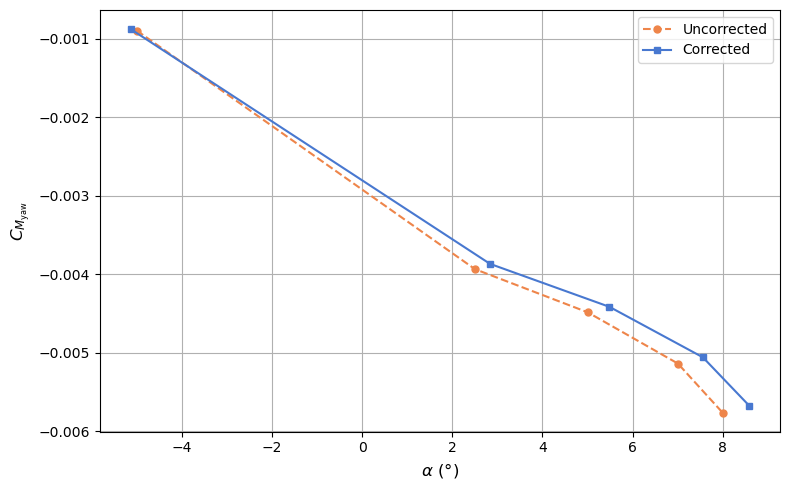

Saved: propon_CMyaw_vs_AoA_J2p4ppng


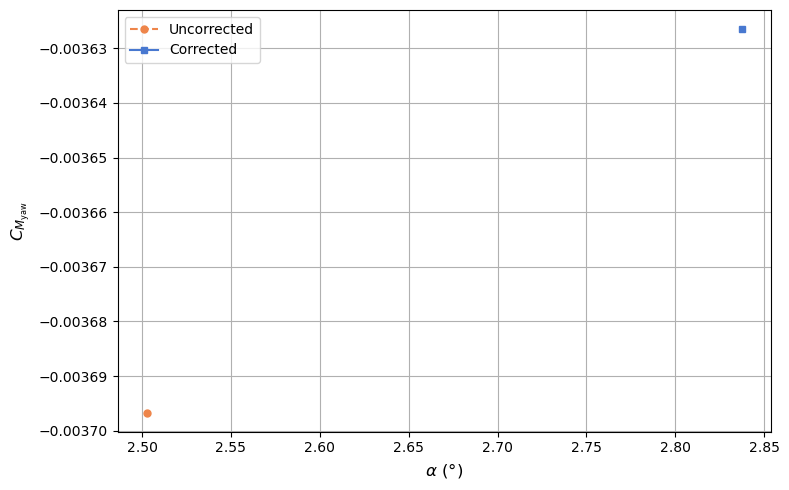

Saved: propon_CMyaw_vs_AoA_J2p8ppng


In [80]:
# -- Prop-on: CMyaw vs AoA -- individual figure per J (all J values)
j_values_all = sorted(df_on["J_round"].unique())

for j_val in j_values_all:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    x_aoa = grp["AoA"].to_numpy(dtype=float)
    x_fin = grp["AoA_FINAL"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_aoa, grp["CMyaw"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW, color=COLORS[1], label="Uncorrected")
    ax.plot(x_fin, grp["CMyaw_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR, color=COLORS[0], label="Corrected")

    ax.set_xlabel(r"$\alpha$ (°)")
    ax.set_ylabel(r"$C_{M_\mathrm{yaw}}$")
    if SHOW_TITLE:
        ax.set_title(fr"$C_{{M_\mathrm{{yaw}}}}$ vs $\alpha$ -- Prop-on ($J$ = {j_val})")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    save_name = f"propon_CMyaw_vs_AoA_J{j_val}.png".replace(".", "p")
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=150)
    plt.show()
    print(f"Saved: {save_name}")


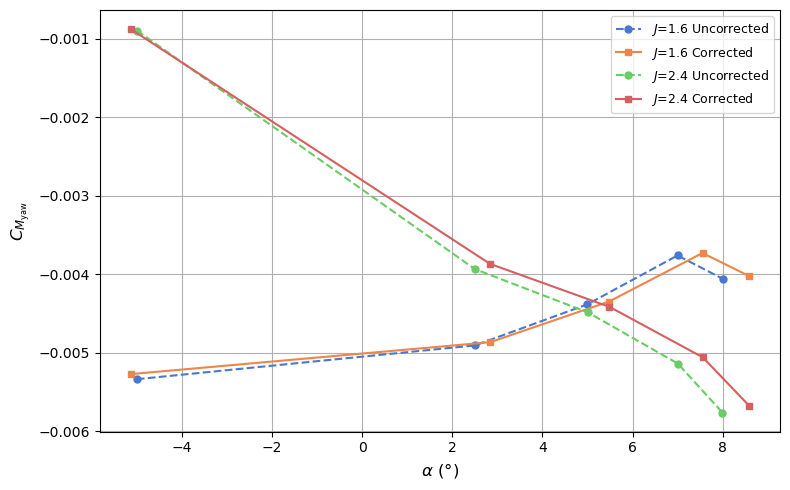

In [81]:
# -- Prop-on: CMyaw vs AoA -- combined figure J=1.6 and J=2.4
# 4 distinct colours: 2 per J, cycled sequentially (colour encodes individual line)
fig, ax = plt.subplots(figsize=(8, 5))

color_idx = 0
for j_val in J_COMBINED:
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
    if grp.empty:
        print(f"No data for J={j_val}"); continue

    ax.plot(grp["AoA"].to_numpy(dtype=float), grp["CMyaw"].to_numpy(dtype=float),
            marker=MK_RAW, markersize=MS, linestyle=LS_RAW,
            color=COLORS[color_idx], label=fr"$J$={j_val} Uncorrected")
    ax.plot(grp["AoA_FINAL"].to_numpy(dtype=float), grp["CMyaw_FINAL"].to_numpy(dtype=float),
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[color_idx + 1], label=fr"$J$={j_val} Corrected")
    color_idx += 2

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{yaw}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{yaw}}$ vs $\alpha$ -- Prop-on, $J$ = 1.6 & 2.4 (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_CMyaw_vs_AoA_J16_J24_combined.png"), dpi=150)
plt.show()


### 3.6  Drag polar -- prop-on FINAL vs prop-off FINAL

All J values on one plot; prop-off shown as dashed grey reference.

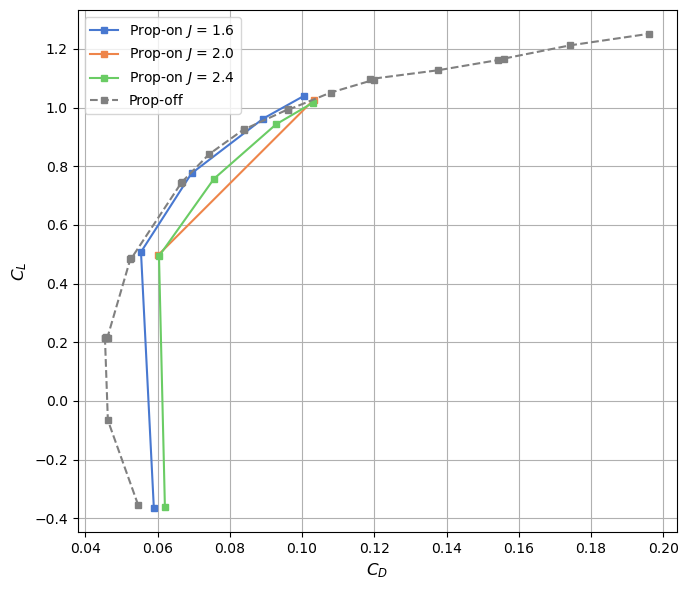

In [82]:
# -- Prop-on vs prop-off drag polar (FINAL); all J values
j_values_all = sorted(df_on["J_round"].unique())

fig, ax = plt.subplots(figsize=(7, 6))

for idx, j_val in enumerate(j_values_all):
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")

    x = grp["CD_FINAL"].to_numpy(dtype=float)
    y = grp["CL_FINAL"].to_numpy(dtype=float)
    fin = np.isfinite(x) & np.isfinite(y)
    if fin.sum() < 2:
        continue

    ax.plot(x[fin], y[fin],
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[idx % len(COLORS)],
            label=fr"Prop-on $J$ = {j_val}")

grp_off = df_off[
    (df_off["V_round"]   == 40) &
    (df_off["AoS_round"] == 0)  &
    (df_off["dR"]        == 0)  &
    (df_off["dE"]        == 0)
].copy().sort_values("AoA_FINAL")

x_off = grp_off["CD_FINAL"].to_numpy(dtype=float)
y_off = grp_off["CL_FINAL"].to_numpy(dtype=float)
fin_off = np.isfinite(x_off) & np.isfinite(y_off)
ax.plot(x_off[fin_off], y_off[fin_off],
        marker=MK_COR, markersize=MS - 1, linestyle=LS_RAW,
        color="gray", label="Prop-off")

ax.set_xlabel(r"$C_D$")
ax.set_ylabel(r"$C_L$")
if SHOW_TITLE:
    ax.set_title(r"Drag polar (FINAL) -- Prop-on vs Prop-off (V = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_vs_propoff_polar_FINAL.png"), dpi=150)
plt.show()


### 3.7-3.9  Wall-correction increments vs $\alpha$

$\Delta C = C_\mathrm{FINAL} - C_\mathrm{BEM}$ -- shift added by wall corrections on top of BEM thrust separation. All J values on one plot per coefficient.

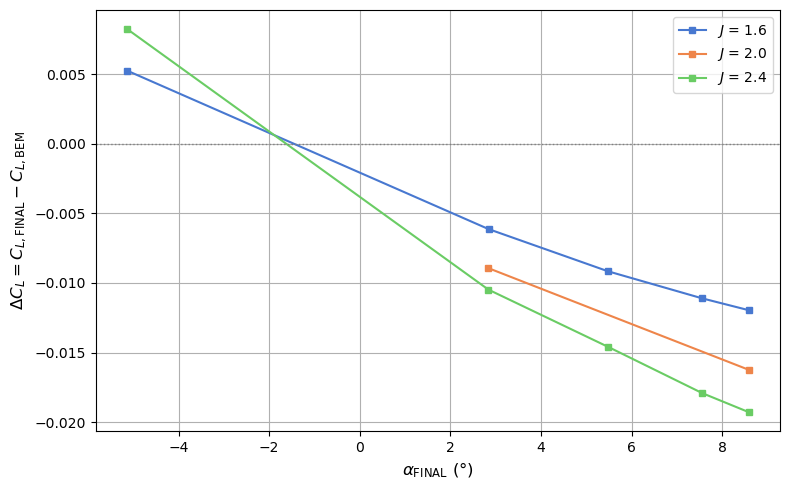

In [83]:
# -- Prop-on: delta-CL = CL_FINAL - CL_aero_BEM vs AoA_FINAL; all J on one plot
j_values_all = sorted(df_on["J_round"].unique())

fig, ax = plt.subplots(figsize=(8, 5))

for idx, j_val in enumerate(j_values_all):
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")

    x     = grp["AoA_FINAL"].to_numpy(dtype=float)
    delta = grp["CL_FINAL"].to_numpy(dtype=float) - grp["CL_aero_BEM"].to_numpy(dtype=float)
    fin   = np.isfinite(x) & np.isfinite(delta)
    if fin.sum() < 2:
        continue

    ax.plot(x[fin], delta[fin],
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[idx % len(COLORS)],
            label=fr"$J$ = {j_val}")

ax.axhline(0, color="gray", linestyle=":", linewidth=1.0)
ax.set_xlabel(r"$\alpha_\mathrm{FINAL}$ (°)")
ax.set_ylabel(r"$\Delta C_L = C_{L,\mathrm{FINAL}} - C_{L,\mathrm{BEM}}$")
if SHOW_TITLE:
    ax.set_title(r"$\Delta CL$ wall-correction increment -- Prop-on")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_delta_CL.png"), dpi=150)
plt.show()


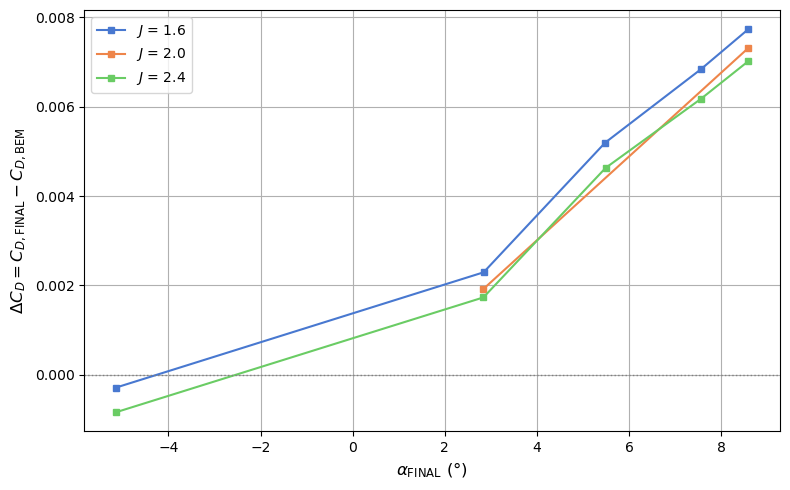

In [84]:
# -- Prop-on: delta-CD = CD_FINAL - CD_aero_BEM vs AoA_FINAL; all J on one plot
j_values_all = sorted(df_on["J_round"].unique())

fig, ax = plt.subplots(figsize=(8, 5))

for idx, j_val in enumerate(j_values_all):
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")

    x     = grp["AoA_FINAL"].to_numpy(dtype=float)
    delta = grp["CD_FINAL"].to_numpy(dtype=float) - grp["CD_aero_BEM"].to_numpy(dtype=float)
    fin   = np.isfinite(x) & np.isfinite(delta)
    if fin.sum() < 2:
        continue

    ax.plot(x[fin], delta[fin],
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[idx % len(COLORS)],
            label=fr"$J$ = {j_val}")

ax.axhline(0, color="gray", linestyle=":", linewidth=1.0)
ax.set_xlabel(r"$\alpha_\mathrm{FINAL}$ (°)")
ax.set_ylabel(r"$\Delta C_D = C_{D,\mathrm{FINAL}} - C_{D,\mathrm{BEM}}$")
if SHOW_TITLE:
    ax.set_title(r"$\Delta CD$ wall-correction increment -- Prop-on")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_delta_CD.png"), dpi=150)
plt.show()


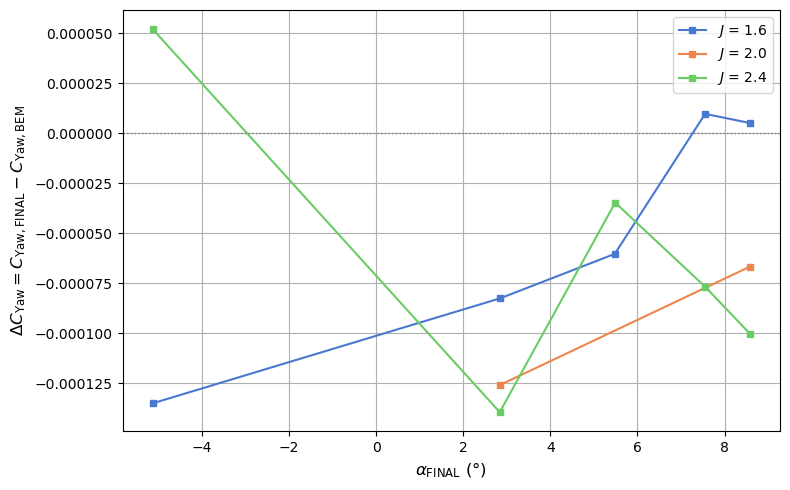

In [85]:
# -- Prop-on: delta-CYaw = CYaw_FINAL - CYaw_aero_BEM vs AoA_FINAL; all J on one plot
j_values_all = sorted(df_on["J_round"].unique())

fig, ax = plt.subplots(figsize=(8, 5))

for idx, j_val in enumerate(j_values_all):
    grp = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")

    x     = grp["AoA_FINAL"].to_numpy(dtype=float)
    delta = grp["CYaw_FINAL"].to_numpy(dtype=float) - grp["CYaw_aero_BEM"].to_numpy(dtype=float)
    fin   = np.isfinite(x) & np.isfinite(delta)
    if fin.sum() < 2:
        continue

    ax.plot(x[fin], delta[fin],
            marker=MK_COR, markersize=MS, linestyle=LS_COR,
            color=COLORS[idx % len(COLORS)],
            label=fr"$J$ = {j_val}")

ax.axhline(0, color="gray", linestyle=":", linewidth=1.0)
ax.set_xlabel(r"$\alpha_\mathrm{FINAL}$ (°)")
ax.set_ylabel(r"$\Delta C_\mathrm{Yaw} = C_{\mathrm{Yaw},\mathrm{FINAL}} - C_{\mathrm{Yaw},\mathrm{BEM}}$")
if SHOW_TITLE:
    ax.set_title(r"$\Delta CYaw$ wall-correction increment -- Prop-on")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_delta_CYaw.png"), dpi=150)
plt.show()
